## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x00000174CE50E980> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2009-2023_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.707075
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.247922
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.767318
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.002822
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073459


In [6]:
timeline_file.shape

(3544266, 33)

In [7]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


In [8]:
wnv_file.shape

(420, 4)

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [11]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [13]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [14]:
dataset.dtypes

NUTS2_ID                      object
NUTS2_NAME                    object
NUTS3_ID                      object
NUTS3_NAME                    object
x                            float64
y                            float64
dt_placement          datetime64[ns]
year                           int64
month                          int64
day                            int64
ndvi                         float64
ndmi                         float64
ndwi                         float64
ndbi                         float64
ndvi_mean                    float64
ndmi_mean                    float64
ndwi_mean                    float64
ndbi_mean                    float64
ndvi_std                     float64
ndmi_std                     float64
ndwi_std                     float64
ndbi_std                     float64
lst_day                      float64
lst_night                    float64
lst_jan_day_mean             float64
lst_feb_day_mean             float64
lst_mar_day_mean             float64
l

In [15]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))

In [16]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [17]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [18]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [19]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

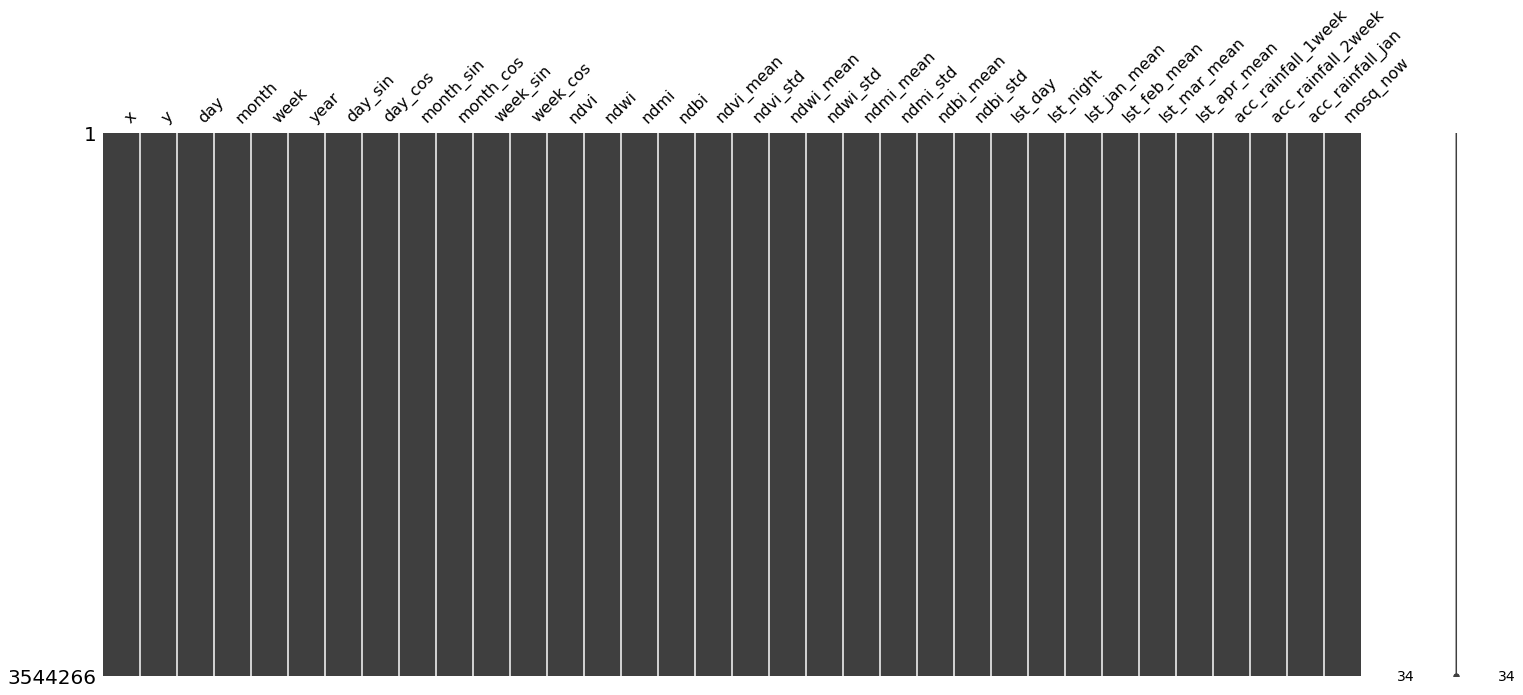

In [20]:
missingno.matrix(dataset_mamoth)

In [21]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [22]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [23]:
predictions = give_predictions(model, dataset_mamoth)

In [24]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.784690,40.821750,2009-01-01,36
1,21.784690,40.821750,2009-01-02,35
2,21.784690,40.821750,2009-01-03,35
3,21.784690,40.821750,2009-01-04,34
4,21.784690,40.821750,2009-01-05,9
...,...,...,...,...
3544261,24.070040,40.980230,2023-12-27,10
3544262,24.070040,40.980230,2023-12-28,10
3544263,24.070040,40.980230,2023-12-29,42
3544264,24.070040,40.980230,2023-12-30,43


<AxesSubplot:>

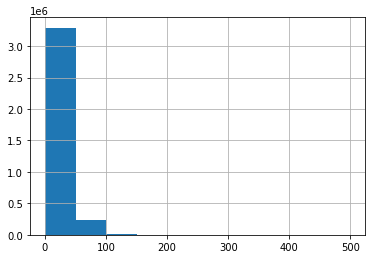

In [25]:
mosqutio_predictions.mosq_pred.hist()

In [12]:
# mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc, index = False)

mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

dataset = timeline_file

In [13]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [14]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.707075,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,36
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.247922,NaN,NaN,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,35
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.767318,NaN,NaN,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,35
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.002822,NaN,NaN,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,34
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073459,NaN,NaN,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3544261,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.926420,40.090620,2023-12-27,2023,12,27,0.689044,0.337848,-0.563306,-0.337848,0.665467,0.377076,-0.526607,-0.377076,0.042357,0.063478,0.055688,0.063478,14291.000000,14129.000000,14228.677419,14093.785714,14277.903226,14277.903226,13983.032258,13870.214286,14011.870968,14011.870968,0.278896,14210.000000,14105.854839,13982.000000,14144.887097,14144.887097,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,5
3544262,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.926420,40.090620,2023-12-28,2023,12,28,0.689044,0.337848,-0.563306,-0.337848,0.665467,0.377076,-0.526607,-0.377076,0.042357,0.063478,0.055688,0.063478,14291.000000,14131.000000,14228.677419,14093.785714,14277.903226,14277.903226,13983.032258,13870.214286,14011.870968,14011.870968,0.000000,14211.000000,14105.854839,13982.000000,14144.887097,14144.887097,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,5
3544263,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.926420,40.090620,2023-12-29,2023,12,29,0.288175,0.301424,-0.185586,-0.301424,0.443428,0.378124,-0.296388,-0.378124,0.161888,0.080712,0.161997,0.080712,14291.000000,14131.000000,14228.677419,14093.785714,14277.903226,14277.903226,13983.032258,13870.214286,14011.870968,14011.870968,8.754433,14211.000000,14105.854839,13982.000000,14144.887097,14144.887097,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,3
3544264,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.926420,40.090620,2023-12-30,2023,12,30,0.288175,0.301424,-0.185586,-0.301424,0.443428,0.378124,-0.296388,-0.378124,0.161888,0.080712,0.161997,0.080712,14291.000000,14131.000000,14228.677419,14093.785714,14277.903226,14277.903226,13983.032258,13870.214286,14011.870968,14011.870968,0.000000,14211.000000,14105.854839,13982.000000,14144.887097,14144.887097,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,3


In [15]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [16]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [17]:
dataset_locations

,x,y
0,21.961760,40.524410
1,22.226790,40.564840
2,22.226790,40.605260
3,22.226790,40.645690
4,22.279790,40.403140
...,...,...
642,23.399410,40.373600
643,23.399410,40.333180
644,23.399410,40.090620
645,23.557510,39.969350


In [18]:
dataset_locations_per_year

,x,y,year
0,21.961760,40.524410,2009
1,22.226790,40.564840,2009
2,22.226790,40.605260,2009
3,22.226790,40.645690,2009
4,22.279790,40.403140,2009
...,...,...,...
9700,23.399410,40.373600,2023
9701,23.399410,40.333180,2023
9702,23.399410,40.090620,2023
9703,23.557510,39.969350,2023


In [19]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [20]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 7.073230889886872e-13


In [21]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [22]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.961760,40.524410,14037.632058,2449.621272,18,223.200531,1544.195600,186.326434,0.000000,1.954261
1,22.226790,40.564840,8767.317534,377.623624,2,89.551308,45.802497,178.927911,0.000000,1.000000
2,22.226790,40.605260,13137.174898,2037.043472,2,126.638503,23.111221,178.741379,0.000000,5.799629
3,22.226790,40.645690,17568.081572,709.587507,2,159.935983,11.607790,179.532658,0.000000,10.927601
4,22.279790,40.403140,6670.256307,3839.763398,4,85.790623,1010.446996,168.465269,0.000000,6.974586
...,...,...,...,...,...,...,...,...,...,...
642,23.399410,40.373600,10447.062495,226.767122,10,179.459504,354.792018,189.067724,0.000000,39.370204
643,23.399410,40.333180,5959.987923,2144.717287,7,187.781808,193.398766,182.761362,0.000000,5.082648
644,23.399410,40.090620,3315.239017,3096.850396,3,119.244541,74.979740,179.943180,0.000000,1.109039
645,23.557510,39.969350,3247.858924,10151.315676,35,176.822147,216.733225,182.777285,0.000000,1.000000


In [23]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [24]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [25]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [26]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.961760,40.524410,14037.632058,2449.621272,18,223.200531,1544.195600,186.326434,0.000000,1.954261
1,22.226790,40.564840,8767.317534,377.623624,2,89.551308,45.802497,178.927911,0.000000,1.000000
2,22.226790,40.605260,13137.174898,2037.043472,2,126.638503,23.111221,178.741379,0.000000,5.799629
3,22.226790,40.645690,17568.081572,709.587507,2,159.935983,11.607790,179.532658,0.000000,10.927601
4,22.279790,40.403140,6670.256307,3839.763398,4,85.790623,1010.446996,168.465269,0.000000,6.974586
...,...,...,...,...,...,...,...,...,...,...
642,23.399410,40.373600,10447.062495,226.767122,10,179.459504,354.792018,189.067724,0.000000,39.370204
643,23.399410,40.333180,5959.987923,2144.717287,7,187.781808,193.398766,182.761362,0.000000,5.082648
644,23.399410,40.090620,3315.239017,3096.850396,3,119.244541,74.979740,179.943180,0.000000,1.109039
645,23.557510,39.969350,3247.858924,10151.315676,35,176.822147,216.733225,182.777285,0.000000,1.000000


In [28]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [29]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [30]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [31]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [32]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [33]:
landcover_2023 = landcover_2022

In [34]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2010
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2011
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2012
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2013
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2014
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2015
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2016
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2017
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2018
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2019
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2020
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2021
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2022
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2023
Min distance: 0.0
Max distance: 7.073230889886872e-13


In [35]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [36]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.961760,40.524410,2009,31,91.000000,30,91.000000,30,91.000000,10,10,1,6,6,2,0
1,22.226790,40.564840,2009,22,76.000000,25,82.000000,20,76.000000,14,9,4,2,2,2,0
2,22.226790,40.605260,2009,31,86.000000,36,88.000000,30,86.000000,12,12,1,6,7,2,0
3,22.226790,40.645690,2009,31,88.000000,36,90.000000,30,88.000000,12,12,1,6,7,2,0
4,22.279790,40.403140,2009,21,84.000000,20,84.000000,20,84.000000,8,8,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9700,23.399410,40.373600,2023,21,69.000000,20,69.000000,20,69.000000,8,8,4,1,1,2,0
9701,23.399410,40.333180,2023,22,79.000000,20,79.000000,20,79.000000,9,9,4,1,1,2,0
9702,23.399410,40.090620,2023,31,99.000000,36,98.000000,30,99.000000,12,12,1,6,7,2,0
9703,23.557510,39.969350,2023,21,79.000000,20,79.000000,20,79.000000,8,8,4,2,2,2,0


In [37]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [38]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [39]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [40]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.707075,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,36,14037.632058,2449.621272,18,223.200531,1544.195600,186.326434,0.000000,1.954261,31,91.000000,30,91.000000,30,91.000000,10,10,1,6,6,2,0
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.247922,NaN,NaN,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,35,14037.632058,2449.621272,18,223.200531,1544.195600,186.326434,0.000000,1.954261,31,91.000000,30,91.000000,30,91.000000,10,10,1,6,6,2,0
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.767318,NaN,NaN,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,35,14037.632058,2449.621272,18,223.200531,1544.195600,186.326434,0.000000,1.954261,31,91.000000,30,91.000000,30,91.000000,10,10,1,6,6,2,0
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.002822,NaN,NaN,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,34,14037.632058,2449.621272,18,223.200531,1544.195600,186.326434,0.000000,1.954261,31,91.000000,30,91.000000,30,91.000000,10,10,1,6,6,2,0
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.524410,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,NaN,13563.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073459,NaN,NaN,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,33,14037.632058,2449.621272,18,223.200531,1544.195600,186.326434,0.000000,1.954261,31,91.000000,30,91.000000,30,91.000000,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3544261,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.926420,40.090620,2023-12-27,2023,12,27,0.689044,0.337848,-0.563306,-0.337848,0.665467,0.377076,-0.526607,-0.377076,0.042357,0.063478,0.055688,0.063478,14291.000000,14129.000000,14228.677419,14093.785714,14277.903226,14277.903226,13983.032258,13870.214286,14011.870968,14011.870968,0.278896,14210.000000,14105.854839,13982.000000,14144.887097,14144.887097,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,5,4500.197734,2743.612191,31,173.083272,350.270069,160.270016,0.000000,3.207490,12,97.000000,10,96.000000,10,96.000000,2,2,5,2,2,2,0
3544262,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.926420,40.090620,2023-12-28,2023,12,28,0.689044,0.337848,-0.563306,-0.337848,0.665467,0.377076,-0.526607,-0.377076,0.042357,0.063478,0.055688,0.063478,14291.000000,14131.000000,14228.677419,14093.785714,14277.903226,14277.903226,13983.032258,13870.214286,14011.870968,14011.870968,0.000000,14211.00000

In [41]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [42]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [43]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [44]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [45]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [46]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.173780,40.605260,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13618.000000,13098.000000,13618.000000,NaN,NaN,NaN,13098.000000,NaN,NaN,NaN,10.126079,13371.000000,13371.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,39,430.952681,91.643222,2,53.475540,2.926239,142.953571,0.000000,1.000000,31,99.000000,36,97.000000,30,95.000000,12,12,1,6,7,2,0
1,2009-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.047450,40.693950,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13766.000000,NaN,13766.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.368333,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,35,0.000000,27.527920,2,0.000000,-0.110060,166.990069,0.000000,1.000000,31,97.000000,30,99.000000,30,97.000000,10,10,1,6,6,2,0
2,2009-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.812230,41.014080,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13862.000000,NaN,13862.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.578945,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,34,838.981974,55.964179,2,51.972498,21.046828,155.354599,0.000000,1.000000,31,98.000000,36,98.000000,30,98.000000,12,12,3,5,8,2,0
3,2009-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,21.997790,40.821750,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13776.000000,NaN,13776.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.958263,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,38,370.133349,8.811430,3,39.371894,0.345523,128.211168,0.000000,1.000000,31,96.000000,36,89.000000,30,96.000000,12,9,4,4,4,2,0
4,2009-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.499840,40.249300,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13896.000000,NaN,13896.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.912585,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,38,2954.704953,0.550164,3,69.909220,6.318075,133.905980,0.000000,1.000000,31,98.000000,36,97.000000,30,98.000000,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38341,2023-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.812230,41.014080,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13934.481481,13958.750000,14324.483871,14324.483871,13728.193548,13556.035714,13878.612903,13878.612903,NaN,NaN,13782.185185,13840.946429,14080.580645,14080.580645,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,36,838.981974,55.964179,2,51.972498,21.046828,155.354599,0.000000,1.000000,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
38342,2023-12-31,EL52,κεντρικη μακεδονια,EL524,πελλα,21.997790,40.821750,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13801.903226,13598.107143,14598.870968,14598.870968,13506.096774,13671.928571,13835.870968,13835.870968,NaN,NaN,13961.314815,13545.946429,14139.870968,14139.870968,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,51,370.133349,8.811430,3,39.371894,0.345523,128.211168,0.000000,1.000000,31,97.000000,20,86.000000,2

In [47]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.961760,40.403140,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13390.000000,13098.000000,13390.000000,NaN,NaN,NaN,13098.000000,NaN,NaN,NaN,1.998263,13371.000000,13371.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,12,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,11,69.000000,10,69.000000,10,69.000000,1,1,1,1,1,2,0
1,2009-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,22.623090,40.410970,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13622.000000,NaN,13622.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.368333,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,29,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,3,69.000000,3,65.000000,3,65.000000,1,0,0,0,0,1,0
2,2009-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.385070,40.852380,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13537.000000,NaN,13537.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.561330,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,28,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,14,68.000000,10,68.000000,10,68.000000,4,4,1,2,2,2,0
3,2009-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.700480,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13492.000000,NaN,13492.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.935772,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,32,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,14,68.000000,10,68.000000,10,68.000000,4,4,1,2,2,2,0
4,2009-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.236190,40.006750,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13522.000000,NaN,13522.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.495495,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,36,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,11,72.000000,10,61.000000,10,72.000000,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38341,2023-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.385070,40.852380,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13934.481481,13958.750000,14324.483871,14324.483871,13619.419355,13556.035714,13784.096774,13784.096774,NaN,NaN,13782.185185,13840.946429,14080.580645,14080.580645,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,13,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,14,70.000000,10,70.000000,10,70.000000,4,4,1,4,4,2,0
38342,2023-12-31,EL52,κεντρικη μακεδονια,EL524,πελλα,21.784690,40.700480,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13801.903226,13598.107143,13857.419355,13857.419355,13506.096774,13493.071429,13597.161290,13597.161290,NaN,NaN,13654.000000,13545.946429,13727.290323,13727.290323,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,19,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,14,67.0000

In [48]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_night','lst', 'rainfall','mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [49]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2009-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13724.096154,13098.000000,13371.000000,9.577106,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2
1,2009-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13868.814516,NaN,NaN,1.750929,34.773438,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2
2,2009-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13859.956044,NaN,NaN,1.920203,32.619565,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2
3,2009-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13783.549296,NaN,NaN,6.509716,38.568182,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2
4,2009-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13781.219512,NaN,NaN,12.911587,38.577778,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,19425.493249,3343.323414,31,267.844345,1615.280758,184.594734,0.000000,160.233568,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,31,36,30,12,12,1,6,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38341,2023-12-31,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,31,12,2023,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.239130,11937.024369,1406.325900,6.891304,173.111898,244.1920

<AxesSubplot:>

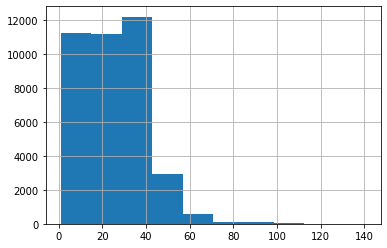

In [50]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [51]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<AxesSubplot:>

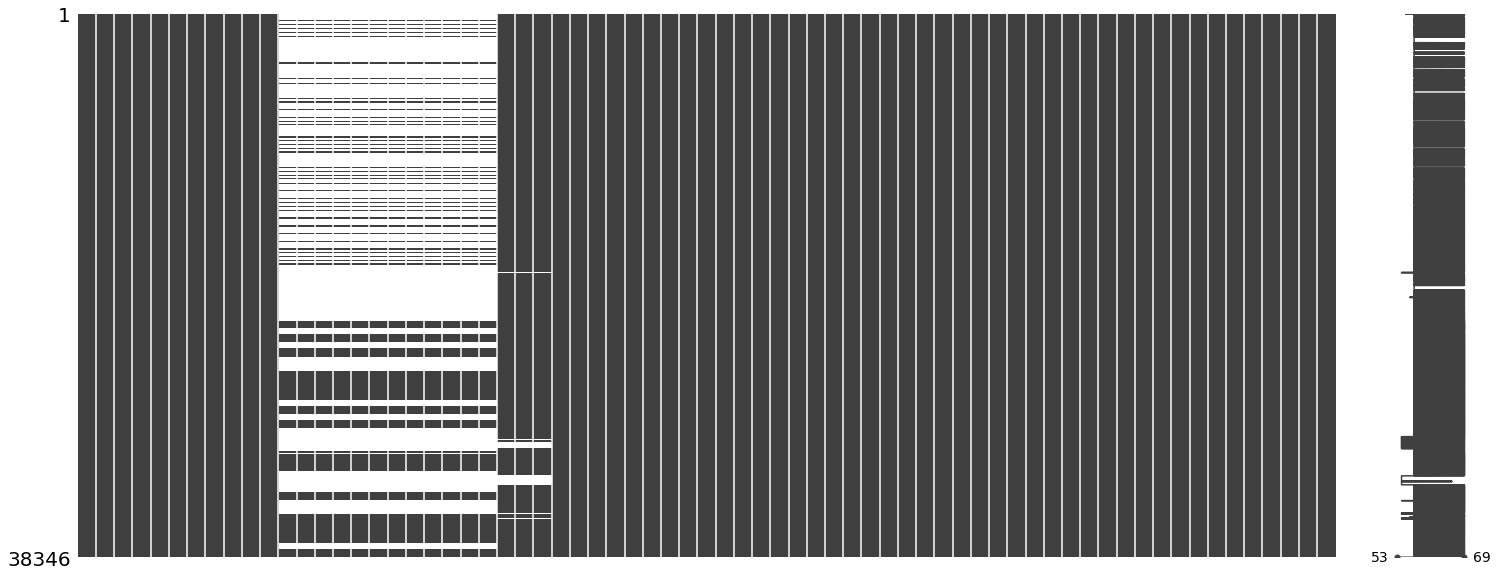

In [52]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [53]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [54]:
bio_values_df = pd.DataFrame(bio_values)

In [55]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,ημαθια,2009,1,-11.190000,12.110000,222.648418
1,ημαθια,2009,2,-4.552963,13.439630,58.031937
2,ημαθια,2009,3,-0.725185,17.720741,77.556888
3,ημαθια,2009,4,3.366604,25.194074,72.607600
4,ημαθια,2009,5,6.810741,33.854815,99.328856
...,...,...,...,...,...,...
1255,χαλκιδικη,2023,8,19.645402,36.664253,1.182073
1256,χαλκιδικη,2023,9,15.600115,32.567701,123.863567
1257,χαλκιδικη,2023,10,12.152529,27.675977,21.629721
1258,χαλκιδικη,2023,11,0.725172,23.450690,251.475013


In [56]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [57]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.331923,-11.190000,-4.929038,9.577106,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418
1,2009-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.226290,NaN,NaN,1.750929,34.773438,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214
2,2009-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.049121,NaN,NaN,1.920203,32.619565,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679
3,2009-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.520986,NaN,NaN,6.509716,38.568182,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2,-8.120000,12.707045,237.353134
4,2009-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.474390,NaN,NaN,12.911587,38.577778,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,19425.493249,3343.323414,31,267.844345,1615.280758,184.594734,0.000000,160.233568,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,31,36,30,12,12,1,6,7,2,-5.454286,13.259778,195.827393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38341,2023-12-31,EL52,κ

<AxesSubplot:>

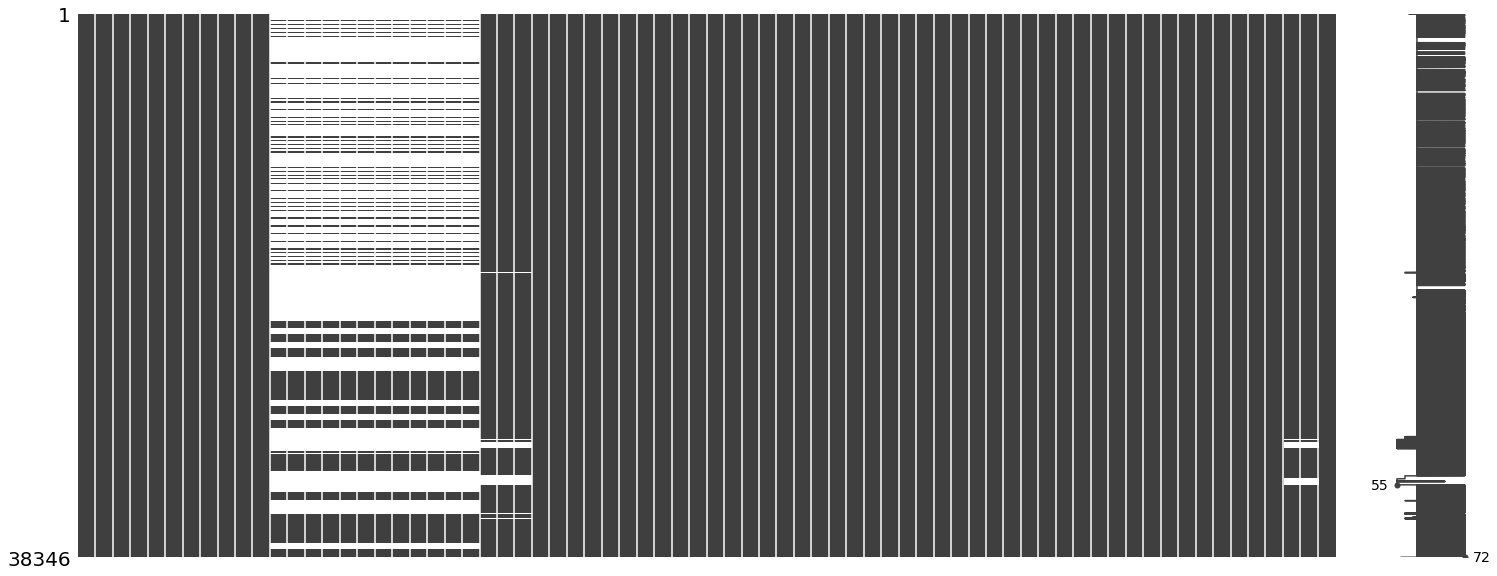

In [58]:
missingno.matrix(dataset)

In [59]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [60]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [61]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2009-01-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.331923,-11.190000,-4.929038,9.577106,37.888889,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,2009-01
1,2009-01-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.226290,NaN,NaN,1.750929,34.773438,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,2009-01
2,2009-01-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.049121,NaN,NaN,1.920203,32.619565,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679,2009-01
3,2009-01-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.520986,NaN,NaN,6.509716,38.568182,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2,-8.120000,12.707045,237.353134,2009-01
4,2009-01-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.474390,NaN,NaN,12.911587,38.577778,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,19425.493249,3343.323414,31,267.844345,1615.280758,184.594734,0.000000,160.233568,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,31,36,30,12,12,1,6,7,2,-5.454286,13.259778,195.827393,2009-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [62]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.263846,-1.414151,-3.130256,0.000000,6.962963,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418
1,1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,1,2009,2,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,2.388548,1.931250,-1.225079,0.000000,1.320312,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214
2,2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,1,2009,2,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,2.930659,-2.247174,-3.030385,0.000000,1.532609,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679
3,3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,1,2009,2,0.107654,0.289068,0.166464,-0.478786,0.132639,0.294365,0.186765,-0.484606,0.036793,0.056441,0.078150,0.056441,0.221795,-6.367647,-3.072926,0.000000,8.113636,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2,-8.120000,12.707045,237.353134
4,4,2009-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.355366,-0.720222,6.583778,0.004667,22.666667,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,19425.493249,3343.323414,31,267.844345,1615.280758,184.594734,0.000000,160.233568,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,31,36,30,12,12,1,6,7,2,-5.454286,13.259778,195.827393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [63]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_month_mean[['x','y']],
                                     grouped_by_month_mods[['month','year']],
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std','lst_day','lst_night','lst','rainfall']],
                                     grouped_by_month_sum[['mosq_pred']],
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [64]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,7.182207,617.518519,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.153071,337.828125,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.194280,310.630435,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679
3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2009,0.128263,0.383927,0.293472,-0.383927,0.138674,0.389485,0.298207,-0.389485,0.039301,0.057925,0.081700,0.057925,5.700504,-1.788882,2.135979,7.656553,565.079545,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2,-8.120000,12.707045,237.353134
4,2009-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.500044,-0.319203,3.157515,6.317013,718.377778,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,19425.493249,3343.323414,31,267.844345,1615.280758,184.594734,0.000000,160.233568,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,31,36,30,12,12,1,6,7,2,-5.454286,13.259778,195.827393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [65]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0


In [66]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1260 non-null   period[M]
 1   NUTS2_ID                1260 non-null   object   
 2   NUTS2_NAME              1260 non-null   object   
 3   NUTS3_ID                1260 non-null   object   
 4   NUTS3_NAME              1260 non-null   object   
 5   x                       1260 non-null   float64  
 6   y                       1260 non-null   float64  
 7   month                   1260 non-null   int64    
 8   year                    1260 non-null   int64    
 9   ndvi                    1184 non-null   float64  
 10  ndmi                    1184 non-null   float64  
 11  ndwi                    1184 non-null   float64  
 12  ndbi                    1184 non-null   float64  
 13  ndvi_mean               1185 non-null   float64  
 14  ndmi_mea

In [67]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    420 non-null    object
 1   NUTS3_NAME    420 non-null    object
 2   dt_placement  420 non-null    object
 3   cases         420 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 13.2+ KB


In [68]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [69]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,κεντρικη μακεδονια,ημαθια,2010-06,0
1,κεντρικη μακεδονια,ημαθια,2010-07,6
2,κεντρικη μακεδονια,ημαθια,2010-08,36
3,κεντρικη μακεδονια,ημαθια,2010-09,7
4,κεντρικη μακεδονια,ημαθια,2010-10,0
...,...,...,...,...
415,κεντρικη μακεδονια,χαλκιδικη,2023-07,0
416,κεντρικη μακεδονια,χαλκιδικη,2023-08,0
417,κεντρικη μακεδονια,χαλκιδικη,2023-09,6
418,κεντρικη μακεδονια,χαλκιδικη,2023-10,0


In [70]:
wnv_file['cases'].value_counts()

0     265
1      42
2      26
3      18
4      13
5       8
6       7
7       6
11      6
10      5
12      4
13      3
8       3
9       2
17      2
20      2
16      1
41      1
27      1
49      1
40      1
50      1
36      1
34      1
Name: cases, dtype: int64

In [71]:
wnv_file.cases.sum()

936

In [72]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [73]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,7.182207,617.518519,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.153071,337.828125,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.194280,310.630435,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679,NaN
3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2009,0.128263,0.383927,0.293472,-0.383927,0.138674,0.389485,0.298207,-0.389485,0.039301,0.057925,0.081700,0.057925,5.700504,-1.788882,2.135979,7.656553,565.079545,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,370.133349,8.811430,0,39.371894,0.345523,128.211168,0.000000,1.000000,31018.597870,3639.993318,35,288.830822,1684.205242,226.669345,1.104109,2894.721638,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,31,36,30,12,9,4,4,4,2,-8.120000,12.707045,237.353134,NaN
4,2009-01,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.500044,-0.319203,3.157515,6.317013,718.377778,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,2954.704953,0.550164,1,69.909220,6.318075,133.905980,0.000000,1.000000,19425.493249,3343.323414,31,267.844345,1615.280758,184.594734,0.000000,160.233568,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,31,36,30,12,12,1,6,7,2,-5.454286,13.259778,195.827393,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [74]:
merged = fillna(merged,{'cases': 0})

In [75]:
merged['cases'].value_counts()

0.000000     1105
1.000000       42
2.000000       26
3.000000       18
4.000000       13
5.000000        8
6.000000        7
11.000000       6
7.000000        6
10.000000       5
12.000000       4
8.000000        3
13.000000       3
9.000000        2
20.000000       2
17.000000       2
41.000000       1
50.000000       1
16.000000       1
34.000000       1
27.000000       1
40.000000       1
49.000000       1
36.000000       1
Name: cases, dtype: int64

In [76]:
merged.cases.sum()

936.0

In [77]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

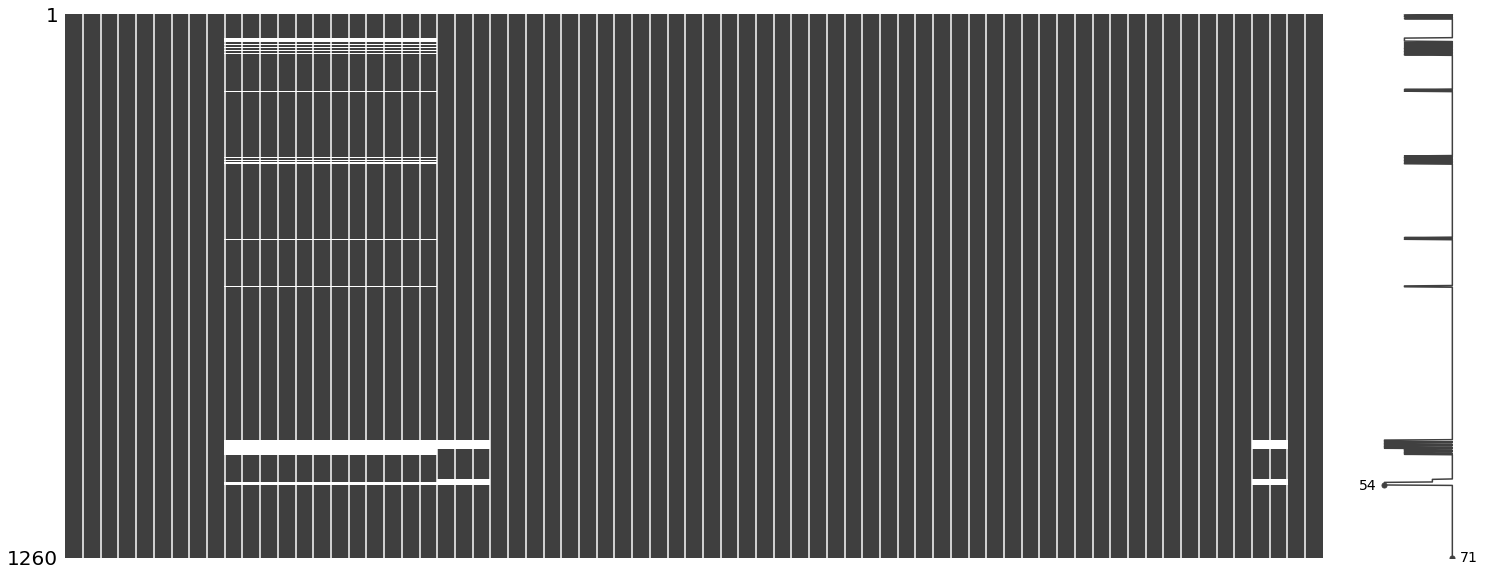

In [78]:
missingno.matrix(merged)

In [79]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

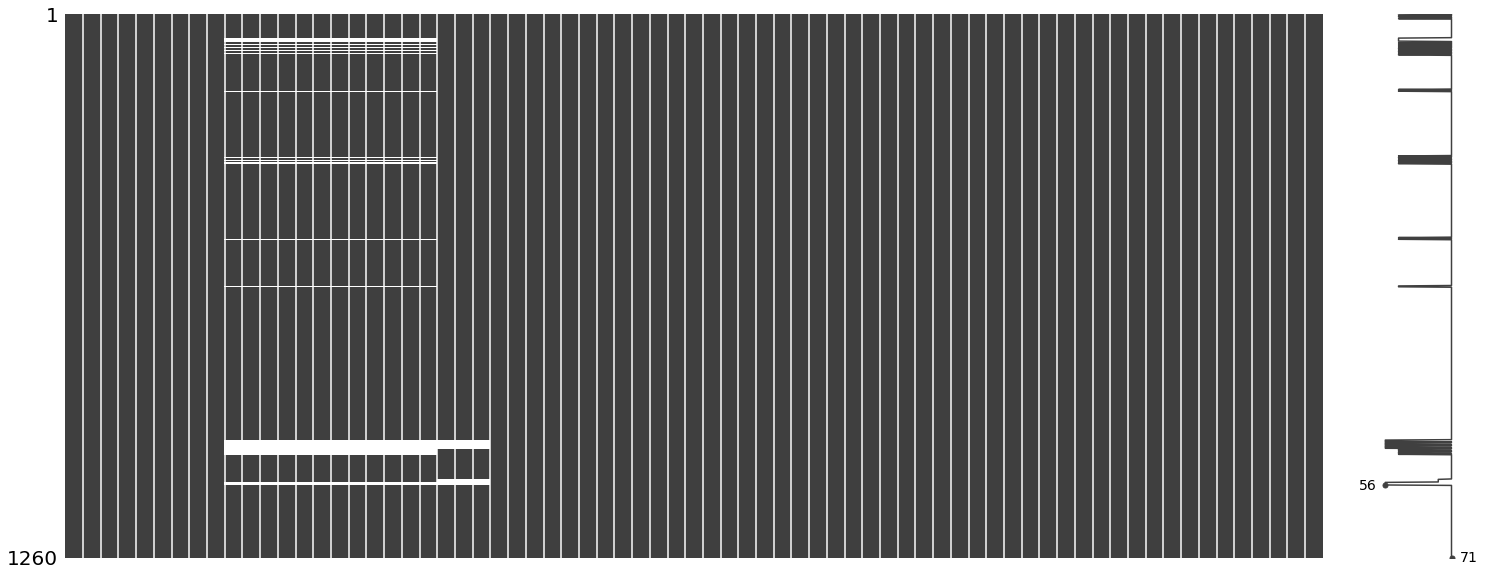

In [80]:
missingno.matrix(merged)

In [81]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023], dtype=int64)

In [82]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['ημαθια', 'θεσσαλονικη', 'κιλκις', 'πελλα', 'πιερια', 'σερρες',
       'χαλκιδικη'], dtype=object)

In [83]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [84]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,ημαθια,2009,14.333333,19.666667,40.972222,832.120329,37.000000,-11.000000,48.000000,5.500000,23.500000,24.000000,4.166667,1455.000000,296.000000,45.000000,62.908014,664.000000,194.000000,259.000000,576.000000
1,θεσσαλονικη,2009,16.083333,21.166667,45.035461,888.265248,42.000000,-5.000000,47.000000,7.166667,9.500000,27.333333,5.666667,1324.000000,291.000000,35.000000,66.632744,587.000000,184.000000,280.000000,547.000000
2,κιλκις,2009,16.041667,22.916667,44.070513,929.187899,44.000000,-8.000000,52.000000,6.666667,9.333333,27.666667,5.333333,1381.000000,286.000000,41.000000,63.457161,604.000000,204.000000,300.000000,550.000000
3,πελλα,2009,14.708333,19.916667,43.297101,849.186331,38.000000,-8.000000,46.000000,6.000000,24.500000,25.166667,4.666667,1512.000000,287.000000,44.000000,60.410595,683.000000,204.000000,288.000000,579.000000
4,πιερια,2009,15.500000,19.500000,43.333333,837.745893,40.000000,-5.000000,45.000000,7.333333,25.166667,26.000000,5.666667,1275.000000,275.000000,51.000000,66.546526,571.000000,176.000000,199.000000,521.000000
5,σερρες,2009,15.291667,19.916667,44.259259,884.065591,39.000000,-6.000000,45.000000,6.166667,9.000000,26.333333,5.000000,1452.000000,260.000000,53.000000,57.846705,581.000000,252.000000,333.000000,567.000000
6,χαλκιδικη,2009,16.000000,19.000000,46.341463,788.266222,39.000000,-2.000000,41.000000,8.833333,9.333333,26.000000,7.000000,1462.000000,378.000000,47.000000,77.636305,694.000000,220.000000,248.000000,411.000000
7,ημαθια,2010,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
8,θεσσαλονικη,2010,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1342.000000,362.000000,8.000000,88.013323,512.000000,158.000000,210.000000,391.000000
9,κιλκις,2010,16.041667,21.416667,46.557971,884.579595,41.000000,-5.000000,46.000000,9.833333,26.000000,26.833333,5.000000,1416.000000,379.000000,10.000000,78.829703,583.000000,198.000000,223.000000,376.000000


In [85]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [86]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'ημαθια')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
84,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.180824,2.759437,4.470131,2.616179,1080.018519,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-0.323333,12.151111,81.101552,0,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
91,2010-02,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.777411,1.447315,4.112363,10.213522,432.962963,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-4.091667,11.750741,285.978611,0,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
98,2010-03,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,3,2010,0.299580,0.137769,-0.145977,-0.137769,0.299260,0.138721,-0.145249,-0.138721,0.042502,0.045998,0.043421,0.045998,16.031804,3.674767,9.853286,3.784360,538.500000,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,0.537778,21.687037,117.315151,0,14.583333,18.500000,48.684211,771.607924,34.000000,-4.000000,38.000000,9.166667,24.000000,24.000000,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
105,2010-04,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4,2010,0.408398,0.144143,-0.235554,-0.144143,0.412976,0.140501,-0.242655,-0.140501,0.044047,0.046857,0.041740,0.046857,22.445667,7.345457,14.895562,2.472640,744.314815,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,4.901481,27.258519,74.179192,0,14.583333,18.5000

In [87]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [88]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [89]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [90]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [91]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

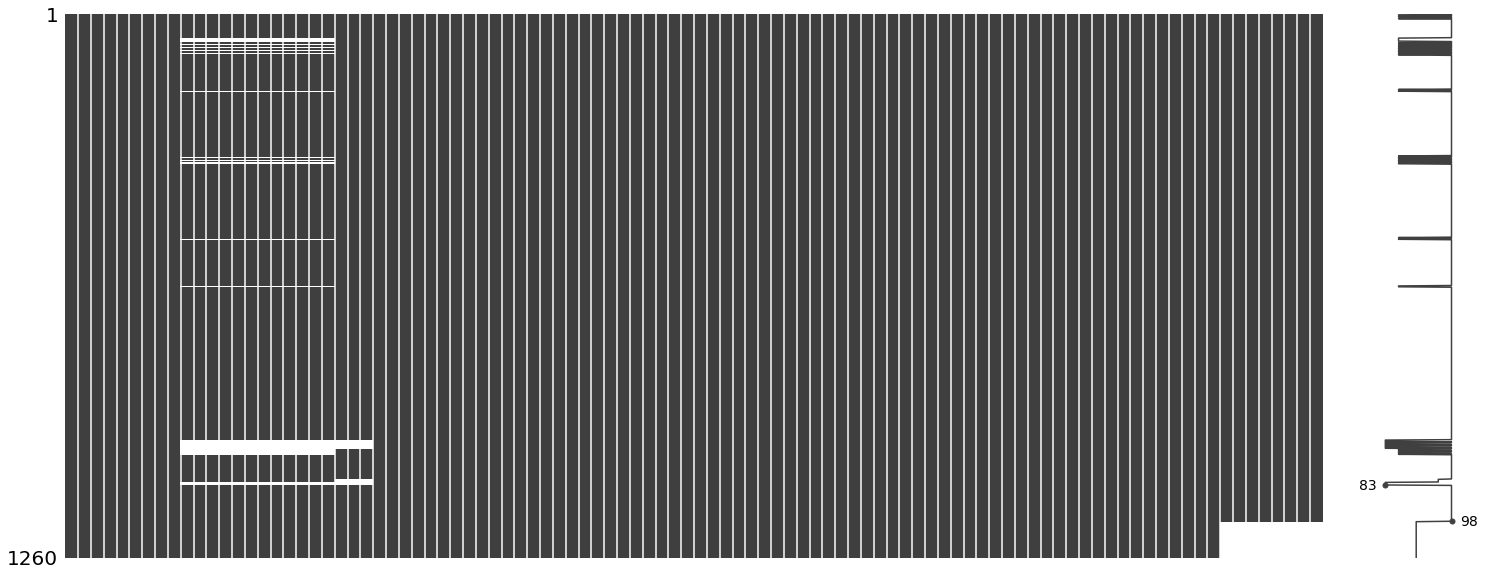

In [92]:
missingno.matrix(dataset)

In [93]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [94]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [95]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [96]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [97]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

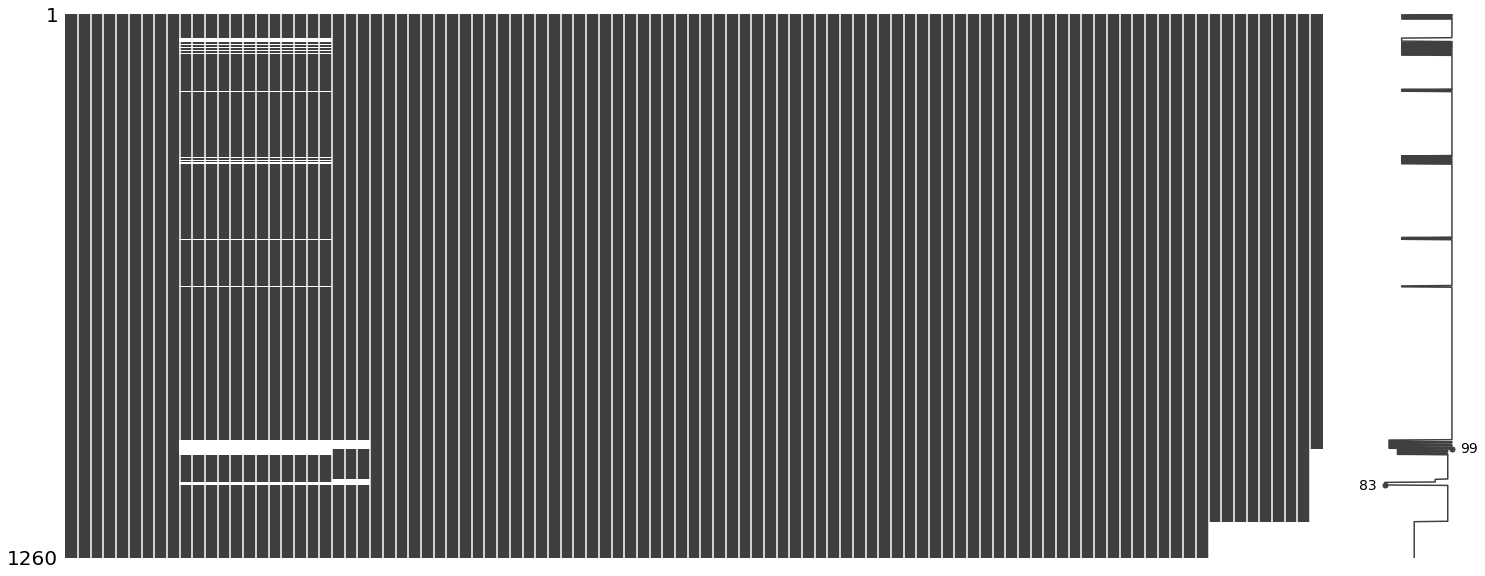

In [98]:
missingno.matrix(dataset)

In [99]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [100]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [101]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [102]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [103]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

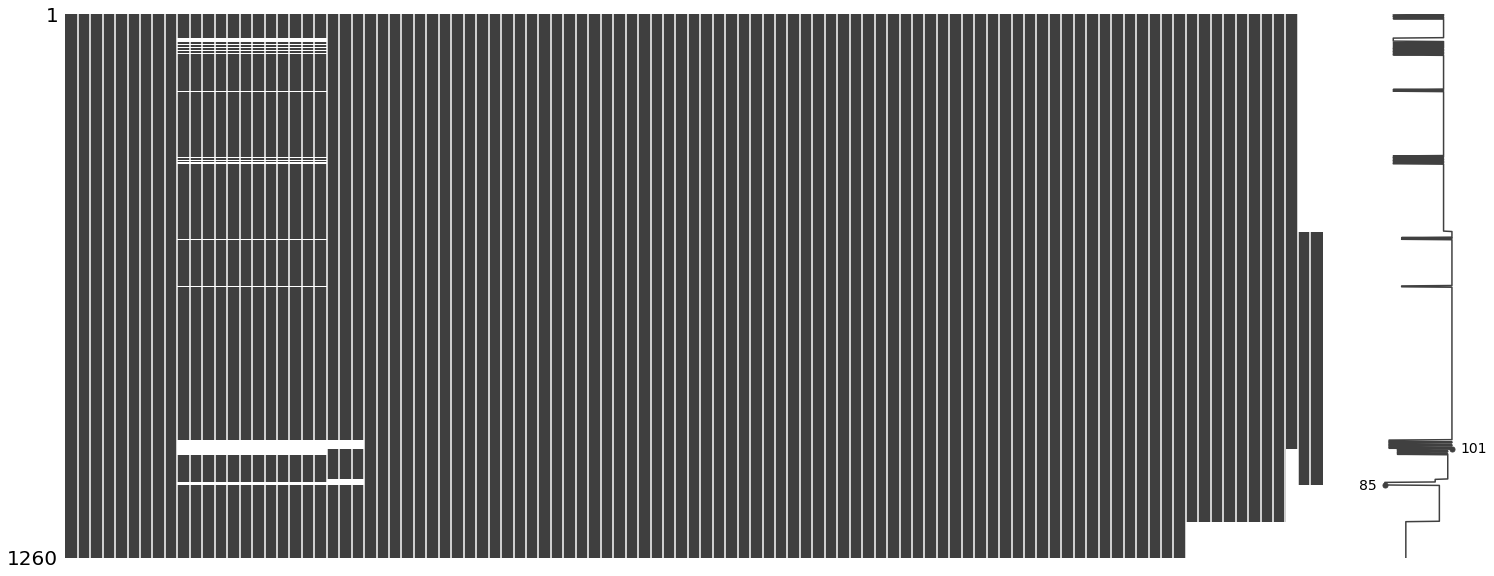

In [104]:
missingno.matrix(dataset)

In [105]:
missing = describe_dataframe(dataset)

In [106]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
96,F_Y_GE65,6.666700
97,F_TOTAL,6.666700
98,MIO_EUR,20.000000
99,L_TOTAL,53.333300


In [107]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,7.182207,617.518519,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.000000,-11.000000,48.000000,5.500000,23.500000,24.000000,4.166667,1455.000000,296.000000,45.000000,62.908014,664.000000,194.000000,259.000000,576.000000,11723.000000,44888.000000,13557.000000,70168.000000,11361.000000,44491.000000,16024.000000,71876.000000,2098.630000,NaN,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.153071,337.828125,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,0,16.083333,21.166667,45.035461,888.265248,42.000000,-5.000000,47.000000,7.166667,9.500000,27.333333,5.666667,1324.000000,291.000000,35.000000,66.632744,587.000000,184.000000,280.000000,547.000000,87281.000000,374669.000000,80103.000000,542053.000000,83839.000000,403005.000000,104992.000000,591836.000000,21520.330000,NaN,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.194280,310.630435,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679,0,16.041667,22.916667,44.070513,929.187899,44.000000,-8.000000,52.000000,6.666667,9.333333,27.666667,5.333333,1381.000000,286.000000,41.000000,63.457161,604.000000,204.000000,300.000000,550.000000,5916.000000,24162.000000,9803.000000,39881.000000,5598.000000,23417.000000,11860.000000,40875.000000,1169.860000,NaN,NaN
3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2009,0.128263,0.383927,0.293472,-0

In [108]:
dataset.reset_index(inplace=True, drop=True)

In [109]:
dataset['cases'].value_counts()

0     1105
1       42
2       26
3       18
4       13
5        8
6        7
11       6
7        6
10       5
12       4
8        3
13       3
9        2
20       2
17       2
41       1
50       1
16       1
34       1
27       1
40       1
49       1
36       1
Name: cases, dtype: int64

In [110]:
dataset['cases'].sum()

936

In [111]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,7.182207,617.518519,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.000000,1.000000,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.000000,-11.000000,48.000000,5.500000,23.500000,24.000000,4.166667,1455.000000,296.000000,45.000000,62.908014,664.000000,194.000000,259.000000,576.000000,11723.000000,44888.000000,13557.000000,70168.000000,11361.000000,44491.000000,16024.000000,71876.000000,2098.630000,NaN,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.153071,337.828125,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.000000,1.000000,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,0,16.083333,21.166667,45.035461,888.265248,42.000000,-5.000000,47.000000,7.166667,9.500000,27.333333,5.666667,1324.000000,291.000000,35.000000,66.632744,587.000000,184.000000,280.000000,547.000000,87281.000000,374669.000000,80103.000000,542053.000000,83839.000000,403005.000000,104992.000000,591836.000000,21520.330000,NaN,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.194280,310.630435,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.000000,1.000000,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,13.098478,223.022679,0,16.041667,22.916667,44.070513,929.187899,44.000000,-8.000000,52.000000,6.666667,9.333333,27.666667,5.333333,1381.000000,286.000000,41.000000,63.457161,604.000000,204.000000,300.000000,550.000000,5916.000000,24162.000000,9803.000000,39881.000000,5598.000000,23417.000000,11860.000000,40875.000000,1169.860000,NaN,NaN
3,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,1,2009,0.128263,0.383927,0.293472,-0

In [112]:
cols = dataset.columns

In [113]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=101)


In [114]:
len(cols)

101

In [115]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc, index = False)
